## Step-1 importing libraries

In [147]:
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## Step-2 read dataset

In [148]:
dataset=pd.read_csv("/Users/user/Downloads/tripadvisor_hotel_reviews.csv")

In [149]:
dataset.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [150]:
dataset.count()

Review    109
Rating    109
dtype: int64

In [151]:
dataset.describe()

,Rating
count,109.000000
mean,3.743119
std,1.293886
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [152]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  109 non-null    object
 1   Rating  109 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


In [153]:
dataset["Review"][0]

'nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  '

## Step-3 Lowercasing the Review

In [154]:
dataset["lowercase"]=dataset["Review"].str.lower()

In [155]:
dataset[["Review","lowercase"]]

,Review,lowercase
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice rooms not 4* experience hotel monaco seat...
3,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso..."
...,...,...
104,"fairmont hotel singapore splendid, stayed fair...","fairmont hotel singapore splendid, stayed fair..."
105,great hotel stayed hotel night route perth chr...,great hotel stayed hotel night route perth chr...
106,great hotel centre stayed 5 nights room overlo...,great hotel centre stayed 5 nights room overlo...
107,great location great value great hotel husband...,great location great value great hotel husband...


## Step-4 Removing stopwords

In [156]:
en_stopwords=stopwords.words('english')
en_stopwords.remove("not")
en_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'o

In [157]:
dataset["removed_stopwords"]=dataset["lowercase"].apply(lambda x: ' '.join( word for word in x.split() if word not in (en_stopwords) ))
dataset["removed_stopwords"]

0      nice hotel expensive parking got good deal sta...
1      ok nothing special charge diamond member hilto...
2      nice rooms not 4* experience hotel monaco seat...
3      unique, great stay, wonderful time hotel monac...
4      great stay great stay, went seahawk game aweso...
                             ...                        
104    fairmont hotel singapore splendid, stayed fair...
105    great hotel stayed hotel night route perth chr...
106    great hotel centre stayed 5 nights room overlo...
107    great location great value great hotel husband...
108    lovely hotel great location stayed vacation to...
Name: removed_stopwords, Length: 109, dtype: object

## Step-5 replacing * with "star" and removing punctuations

In [158]:
dataset['replacing star']=dataset.apply(lambda x: re.sub(r"[*]","star",x["removed_stopwords"]),axis=1)
dataset['replacing star']

0      nice hotel expensive parking got good deal sta...
1      ok nothing special charge diamond member hilto...
2      nice rooms not 4star experience hotel monaco s...
3      unique, great stay, wonderful time hotel monac...
4      great stay great stay, went seahawk game aweso...
                             ...                        
104    fairmont hotel singapore splendid, stayed fair...
105    great hotel stayed hotel night route perth chr...
106    great hotel centre stayed 5 nights room overlo...
107    great location great value great hotel husband...
108    lovely hotel great location stayed vacation to...
Name: replacing star, Length: 109, dtype: object

## Step-6 replace punctuations with blank

In [159]:
dataset['no_punct']=dataset.apply(lambda x: re.sub(r"[^\w\s]","",x['replacing star']),axis=1)
dataset['no_punct']

0      nice hotel expensive parking got good deal sta...
1      ok nothing special charge diamond member hilto...
2      nice rooms not 4star experience hotel monaco s...
3      unique great stay wonderful time hotel monaco ...
4      great stay great stay went seahawk game awesom...
                             ...                        
104    fairmont hotel singapore splendid stayed fairm...
105    great hotel stayed hotel night route perth chr...
106    great hotel centre stayed 5 nights room overlo...
107    great location great value great hotel husband...
108    lovely hotel great location stayed vacation to...
Name: no_punct, Length: 109, dtype: object

## Step-7 Tokenizing 

In [160]:
dataset['tokenized']=dataset.apply(lambda x: word_tokenize(x['no_punct']),axis=1)
dataset['tokenized'][0]

['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'reviews',
 'valet',
 'parking',
 'check',
 'quick',
 'easy',
 'little',
 'disappointed',
 'nonexistent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'size',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillows',
 'not',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bangs',
 'doors',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallway',
 'maybe',
 'noisy',
 'neighbors',
 'aveda',
 'bath',
 'products',
 'nice',
 'not',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longer',
 'location',
 'great',
 'walking',
 'distance',
 'shopping',
 'overall',
 'nice',
 'experience',
 'pay',
 '40',
 'parking',
 'night']

## Step-8 Stemming using PorterStemmer

In [161]:
ps=PorterStemmer()

In [162]:
dataset['stemmed']=dataset['tokenized'].apply(lambda tokens: [ ps.stem(token) for token in tokens ])
print(dataset[['tokenized',"stemmed"]].head())

                                           tokenized  \
0  [nice, hotel, expensive, parking, got, good, d...   
1  [ok, nothing, special, charge, diamond, member...   
2  [nice, rooms, not, 4star, experience, hotel, m...   
3  [unique, great, stay, wonderful, time, hotel, ...   
4  [great, stay, great, stay, went, seahawk, game...   

                                             stemmed  
0  [nice, hotel, expens, park, got, good, deal, s...  
1  [ok, noth, special, charg, diamond, member, hi...  
2  [nice, room, not, 4star, experi, hotel, monaco...  
3  [uniqu, great, stay, wonder, time, hotel, mona...  
4  [great, stay, great, stay, went, seahawk, game...  


## Step-9 lemmatize

In [163]:
lemmatizer=WordNetLemmatizer()

In [164]:
dataset['lemmatized']=dataset['tokenized'].apply(lambda tokens:[ lemmatizer.lemmatize(token) for token in tokens])
dataset[['tokenized','lemmatized']]

,tokenized,lemmatized
0,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expensive, parking, got, good, d..."
1,"[ok, nothing, special, charge, diamond, member...","[ok, nothing, special, charge, diamond, member..."
2,"[nice, rooms, not, 4star, experience, hotel, m...","[nice, room, not, 4star, experience, hotel, mo..."
3,"[unique, great, stay, wonderful, time, hotel, ...","[unique, great, stay, wonderful, time, hotel, ..."
4,"[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game..."
...,...,...
104,"[fairmont, hotel, singapore, splendid, stayed,...","[fairmont, hotel, singapore, splendid, stayed,..."
105,"[great, hotel, stayed, hotel, night, route, pe...","[great, hotel, stayed, hotel, night, route, pe..."
106,"[great, hotel, centre, stayed, 5, nights, room...","[great, hotel, centre, stayed, 5, night, room,..."
107,"[great, location, great, value, great, hotel, ...","[great, location, great, value, great, hotel, ..."


## Step-10 N-gram

In [165]:
tokens_clean = sum(dataset['lemmatized'],[])
tokens_clean

['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'review',
 'valet',
 'parking',
 'check',
 'quick',
 'easy',
 'little',
 'disappointed',
 'nonexistent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'size',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillow',
 'not',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bang',
 'door',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallway',
 'maybe',
 'noisy',
 'neighbor',
 'aveda',
 'bath',
 'product',
 'nice',
 'not',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longer',
 'location',
 'great',
 'walking',
 'distance',
 'shopping',
 'overall',
 'nice',
 'experience',
 'pay',
 '40',
 'parking',
 'night',
 'ok',
 'nothing',
 'special',
 'charge',
 'diamond',
 'member',
 'hilton',
 'decided',
 'chain',
 'shot',
 '20th'

In [166]:
## unigrams
unigrams=(pd.Series(nltk.ngrams(tokens_clean,1)).value_counts())
print(unigrams)

(hotel,)           292
(room,)            275
(great,)           126
(not,)             122
(stay,)             95
                  ... 
(175,)               1
(smackagainst,)      1
(2x,)                1
(80,)                1
(connected,)         1
Name: count, Length: 2589, dtype: int64


In [167]:
##bigrams
bigrams=(pd.Series(nltk.ngrams(tokens_clean,2)).value_counts())
print(bigrams)

(great, location)     24
(space, needle)       21
(hotel, monaco)       16
(great, hotel)        12
(staff, friendly)     12
                      ..
(didnt, make)          1
(personnel, didnt)     1
(minute, stay)         1
(starting, minute)     1
(food, raffle)         1
Name: count, Length: 8263, dtype: int64


In [168]:
##trigrams
trigrams=(pd.Series(nltk.ngrams(tokens_clean,3)).value_counts())
print(trigrams)

(pike, place, market)            8
(view, space, needle)            5
(hotel, great, location)         5
(inn, queen, anne)               4
(room, king, bed)                4
                                ..
(hotel, dissapointment, trip)    1
(dissapointment, trip, 3)        1
(trip, 3, night)                 1
(3, night, stay)                 1
(hotel, right, street)           1
Name: count, Length: 9288, dtype: int64


In [169]:
##4-grams
ngrams_4=(pd.Series(nltk.ngrams(tokens_clean,4)).value_counts())
print(ngrams_4)

(high, floor, great, view)                   2
(definitely, stay, crowne, plaza)            2
(needle, experience, music, project)         2
(nice, hotel, husband, stayed)               2
(really, comfortable, clean, location)       2
                                            ..
(unfortunately, warwick, seattle, hotel)     1
(warwick, seattle, hotel, dissapointment)    1
(seattle, hotel, dissapointment, trip)       1
(hotel, dissapointment, trip, 3)             1
(raffle, hotel, right, street)               1
Name: count, Length: 9387, dtype: int64


## step-11 joining back the tokens for feature engineering

In [170]:
dataset['cleaned_review']=dataset['lemmatized']

In [171]:
dataset['cleaned_review'] = dataset['cleaned_review'].apply(
    lambda x: " ".join(x)
)

## Step-12 Bag of words

In [172]:
bow = CountVectorizer()

In [173]:
dataset['cleaned_review'].head()

0    nice hotel expensive parking got good deal sta...
1    ok nothing special charge diamond member hilto...
2    nice room not 4star experience hotel monaco se...
3    unique great stay wonderful time hotel monaco ...
4    great stay great stay went seahawk game awesom...
Name: cleaned_review, dtype: object

In [174]:
bow = CountVectorizer(
    ngram_range=(1,2)
)

In [175]:
X_bow = bow.fit_transform(dataset['cleaned_review'])

In [176]:
X_bow.shape

(109, 10666)

In [177]:
print(bow.vocabulary_)

{'nice': 6031, 'hotel': 4358, 'expensive': 3178, 'parking': 6680, 'got': 3900, 'good': 3845, 'deal': 2423, 'stay': 9072, 'anniversary': 526, 'arrived': 667, 'late': 5004, 'evening': 3084, 'took': 9692, 'advice': 398, 'previous': 7132, 'review': 7762, 'valet': 10073, 'check': 1727, 'quick': 7314, 'easy': 2890, 'little': 5190, 'disappointed': 2652, 'nonexistent': 6196, 'view': 10111, 'room': 7855, 'clean': 1856, 'size': 8633, 'bed': 1029, 'comfortable': 2008, 'woke': 10542, 'stiff': 9192, 'neck': 5937, 'high': 4240, 'pillow': 6869, 'not': 6217, 'soundproof': 8827, 'like': 5116, 'heard': 4166, 'music': 5899, 'night': 6092, 'morning': 5841, 'loud': 5377, 'bang': 911, 'door': 2719, 'opening': 6516, 'closing': 1953, 'hear': 4154, 'people': 6777, 'talking': 9442, 'hallway': 4085, 'maybe': 5645, 'noisy': 6181, 'neighbor': 6003, 'aveda': 811, 'bath': 947, 'product': 7218, 'goldfish': 3836, 'touch': 9722, 'taken': 9431, 'advantage': 385, 'staying': 9166, 'longer': 5321, 'location': 5250, 'great'

## Step-12 alternative TFIDF

In [178]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2)
)

In [179]:
X_tfidf = tfidf.fit_transform(dataset['cleaned_review'])

In [180]:
print(X_bow.shape)
print(X_tfidf.shape)

(109, 10666)
(109, 10666)


## Step-13 training model with logistic regression

In [181]:
def sentiment_label(rating):

    if rating <= 2:
        return 0

    elif rating == 3:
        return 1

    else:
        return 2

In [182]:
dataset['sentiment'] = dataset['Rating'].apply(sentiment_label)

In [183]:
y = dataset['sentiment']

In [184]:
dataset.head()

,Review,Rating,lowercase,removed_stopwords,replacing star,no_punct,tokenized,stemmed,lemmatized,cleaned_review,sentiment
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expens, park, got, good, deal, s...","[nice, hotel, expensive, parking, got, good, d...",nice hotel expensive parking got good deal sta...,2
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member...","[ok, noth, special, charg, diamond, member, hi...","[ok, nothing, special, charge, diamond, member...",ok nothing special charge diamond member hilto...,0
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms not 4* experience hotel monaco seat...,nice rooms not 4star experience hotel monaco s...,nice rooms not 4star experience hotel monaco s...,"[nice, rooms, not, 4star, experience, hotel, m...","[nice, room, not, 4star, experi, hotel, monaco...","[nice, room, not, 4star, experience, hotel, mo...",nice room not 4star experience hotel monaco se...,1
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,"[unique, great, stay, wonderful, time, hotel, ...","[uniqu, great, stay, wonder, time, hotel, mona...","[unique, great, stay, wonderful, time, hotel, ...",unique great stay wonderful time hotel monaco ...,2
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,"[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game...",great stay great stay went seahawk game awesom...,2


In [185]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bow,
    y,
    test_size=0.2,
    random_state=42
)

In [186]:
model_using_Bow = LogisticRegression()

In [187]:
model_using_Bow.fit(X_train, y_train)

LogisticRegression()

In [188]:
y_pred = model_using_Bow.predict(X_test)

In [189]:
from sklearn.metrics import accuracy_score
Bow_accuracy=accuracy_score(y_test, y_pred)
print(accuracy_score(y_test, y_pred))

0.6818181818181818


In [190]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00         2
           2       0.68      1.00      0.81        15

    accuracy                           0.68        22
   macro avg       0.23      0.33      0.27        22
weighted avg       0.46      0.68      0.55        22



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [191]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[ 0  0  5]
 [ 0  0  2]
 [ 0  0 15]]


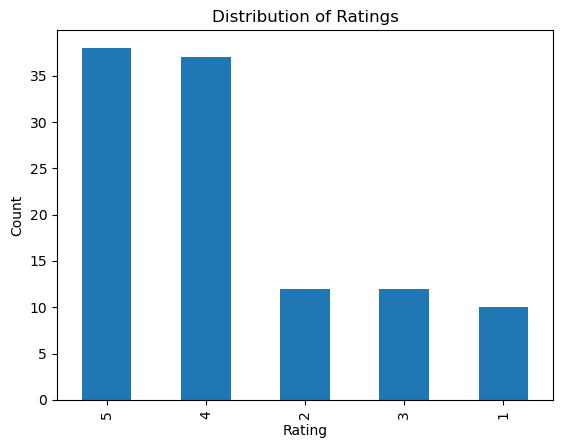

In [192]:
import matplotlib.pyplot as plt

dataset['Rating'].value_counts().plot(kind='bar')

plt.xlabel("Rating")

plt.ylabel("Count")

plt.title("Distribution of Ratings")

plt.show()

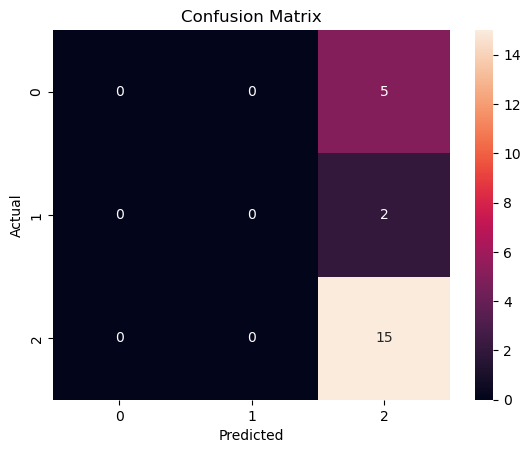

In [193]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Step-14 using TFIDF model training

In [194]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [195]:
model_using_TFIDF = LogisticRegression()

In [196]:
model_using_TFIDF.fit(X_train, y_train)

LogisticRegression()

In [197]:
y_pred_TFIDF = model_using_TFIDF.predict(X_test)

In [198]:
from sklearn.metrics import accuracy_score
tfidf_accuracy=accuracy_score(y_test, y_pred_TFIDF)
print(accuracy_score(y_test, y_pred_TFIDF))

0.6818181818181818


In [199]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_TFIDF))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00         2
           2       0.68      1.00      0.81        15

    accuracy                           0.68        22
   macro avg       0.23      0.33      0.27        22
weighted avg       0.46      0.68      0.55        22



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


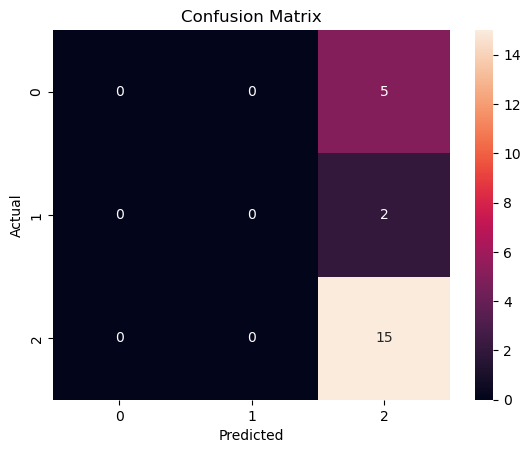

In [200]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm1 = confusion_matrix(y_test, y_pred_TFIDF)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [201]:
comparison = pd.DataFrame({

    'Method': ['BoW', 'TF-IDF'],

    'Accuracy': [Bow_accuracy, tfidf_accuracy]

})

comparison

,Method,Accuracy
0,BoW,0.681818
1,TF-IDF,0.681818


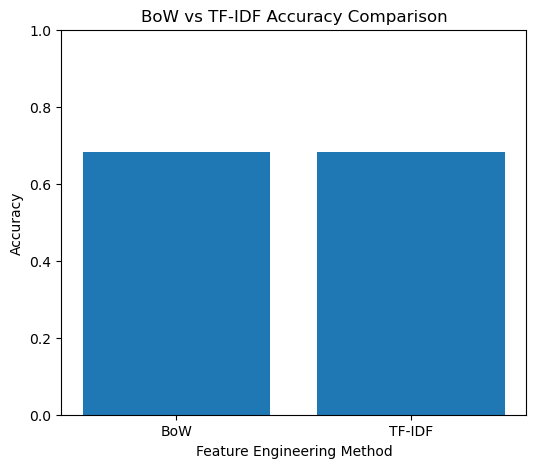

In [202]:
import matplotlib.pyplot as plt

models = ['BoW', 'TF-IDF']

accuracies = [Bow_accuracy, tfidf_accuracy]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.xlabel("Feature Engineering Method")

plt.ylabel("Accuracy")

plt.title("BoW vs TF-IDF Accuracy Comparison")

plt.ylim(0,1)

plt.show()

## Using SVM

In [204]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC()

In [209]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [210]:
svm_model.fit(X_train_svm, y_train_svm)

LinearSVC()

In [211]:
y_pred_svm = svm_model.predict(X_test_svm)

In [212]:
svm_accuracy = accuracy_score(
    y_test_svm,
    y_pred_svm
)

print(svm_accuracy)

0.6818181818181818


In [213]:
dataset['sentiment'].value_counts()

sentiment
2    75
0    22
1    12
Name: count, dtype: int64